# Baseline notebook — TF-IDF + Logistic Regression (10-class error-type classification)
This notebook establishes classical baselines for sentence-level French learner error-type classification (10 labels).
We compare three training setups: (1) synthetic-only, (2) real-only, and (3) synthetic + real (mixed).
Evaluation is performed on the held-out real gold validation set (gold_val), using accuracy and macro-F1 (main metric).
We additionally report per-label precision/recall/F1 and confusion matrices to understand systematic confusions and label overlap.
The best baseline will serve as a reference point for transformer models in the next notebook.Gold_test is not used in this notebook. It will be evaluated exactly once at the end of the project after model selection.

In [ ]:
#Setup and import

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from pathlib import Path


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#load the clean data already preprocessed

BASE_DIR = Path("/content/drive/MyDrive/Final_Project/data/final_splits_clean")

train_syn  = pd.read_csv(BASE_DIR / "train_syn_clean.csv")
train_real = pd.read_csv(BASE_DIR / "train_real_clean.csv")
gold_val   = pd.read_csv(BASE_DIR / "gold_val_clean.csv")


#labels

LABELS = [
    "verb_form",
    "tense_mood_aspect",
    "lexical_choice",
    "agreement",
    "word_order",
    "pronoun_clitic",
    "preposition",
    "determiner_article",
    "negation",
    "spelling_orthography"
]

In [ ]:
train_syn.columns

Index(['learner_sentence', 'label'], dtype='object')

In [ ]:
#train_syn size, train_real size, gold_val size

print("Train_syn size :", train_syn.shape)
print("Train_real size :", train_real.shape)
print("gold val size :", gold_val.shape)

#gold_val label counts

print(f"==== train_syn label counts ====:")
print (train_syn["label"].value_counts())
print ("..............................")

print(f"==== train_real label counts====:")
print(train_real["label"].value_counts())
print ("..............................")

print(f"==== gold_val label counts ====:")
print(gold_val["label"].value_counts())
print ("..............................")


Train_syn size : (14341, 2)
Train_real size : (398, 2)
gold val size : (183, 2)
==== train_syn label counts ====:
label
verb_form               1837
tense_mood_aspect       1674
lexical_choice          1613
agreement               1596
word_order              1482
pronoun_clitic          1439
preposition             1384
negation                1206
spelling_orthography    1056
determiner_article      1054
Name: count, dtype: int64
..............................
==== train_real label counts====:
label
verb_form               74
agreement               52
preposition             48
spelling_orthography    46
determiner_article      43
negation                40
lexical_choice          32
tense_mood_aspect       23
word_order              20
pronoun_clitic          20
Name: count, dtype: int64
..............................
==== gold_val label counts ====:
label
verb_form               32
lexical_choice          31
agreement               23
preposition             20
spelling_orthograph

#Evaluation note (metrics)

With 10 labels, uniform random guessing would yield roughly ~0.10 accuracy. However, gold_val is imbalanced across labels, so accuracy can be misleading; macro-F1 is a more informative summary because it weights each class equally.”

In [ ]:

# X, y

#train_syn
train_syn_X = train_syn["learner_sentence"]
train_syn_y = train_syn["label"]


#train_real
train_real_X = train_real["learner_sentence"]
train_real_y = train_real["label"]

#gold_val
val_gold_X = gold_val["learner_sentence"]
val_gold_y = gold_val["label"]


#metrics

def compute_metrics (y_true, y_pred):
  return {
      "accuracy" : accuracy_score(y_true, y_pred),
      "macro_f1" : f1_score(y_true, y_pred, average="macro")
  }

#define Vectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)


# Experience 1: FIT ON SYNTHETIC DATA ONLY

In [ ]:
#apply Vectorizer on syn_train
vectorizer.fit(train_syn_X)

#transform
train_syn_features = vectorizer.transform(train_syn_X)
val_features = vectorizer.transform(val_gold_X)

print(train_syn_features.shape, len(train_syn_y))
print(val_features.shape, len(val_gold_y))

# Train model on TRAIN_SYN

model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=1)
model.fit(train_syn_features, train_syn_y)

(14341, 169378) 14341
(183, 169378) 183


LogisticRegression(max_iter=1000, n_jobs=1, random_state=42)

In [ ]:
# Evaluate on VAL
val_pred  = model.predict(val_features)

print("shapes (train/val):", train_syn_features.shape, val_features.shape)
print("val metrics:",  compute_metrics(val_gold_y, val_pred))

shapes (train/val): (14341, 169378) (183, 169378)
val metrics: {'accuracy': 0.23497267759562843, 'macro_f1': 0.22399126925465293}



=== Classification report (per label) ===
                      precision    recall  f1-score   support

           verb_form      0.200     0.188     0.194        32
   tense_mood_aspect      0.196     0.769     0.312        13
      lexical_choice      0.000     0.000     0.000        31
           agreement      0.292     0.304     0.298        23
          word_order      0.188     0.300     0.231        10
      pronoun_clitic      0.600     0.300     0.400        10
         preposition      0.250     0.100     0.143        20
  determiner_article      0.500     0.077     0.133        13
            negation      0.273     0.750     0.400        12
spelling_orthography      0.167     0.105     0.129        19

            accuracy                          0.235       183
           macro avg      0.266     0.289     0.224       183
        weighted avg      0.227     0.235     0.193       183


=== Confusion matrix (counts) ===
[[ 6  8  1  6  2  1  2  0  2  4]
 [ 1 10  0  0  1  

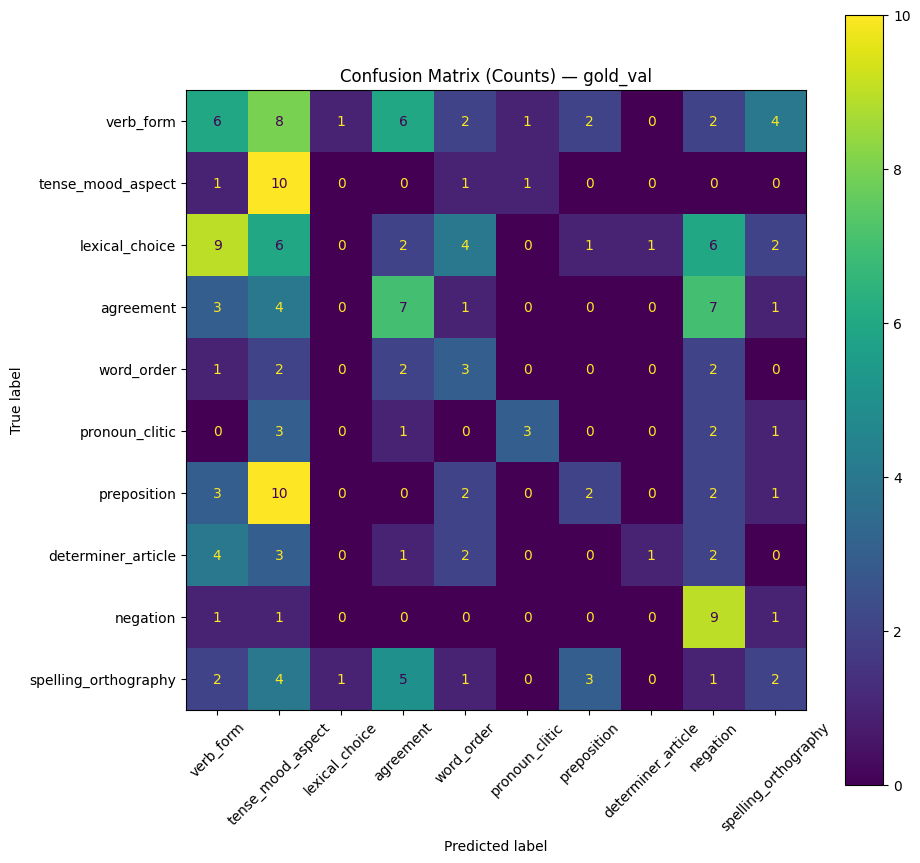

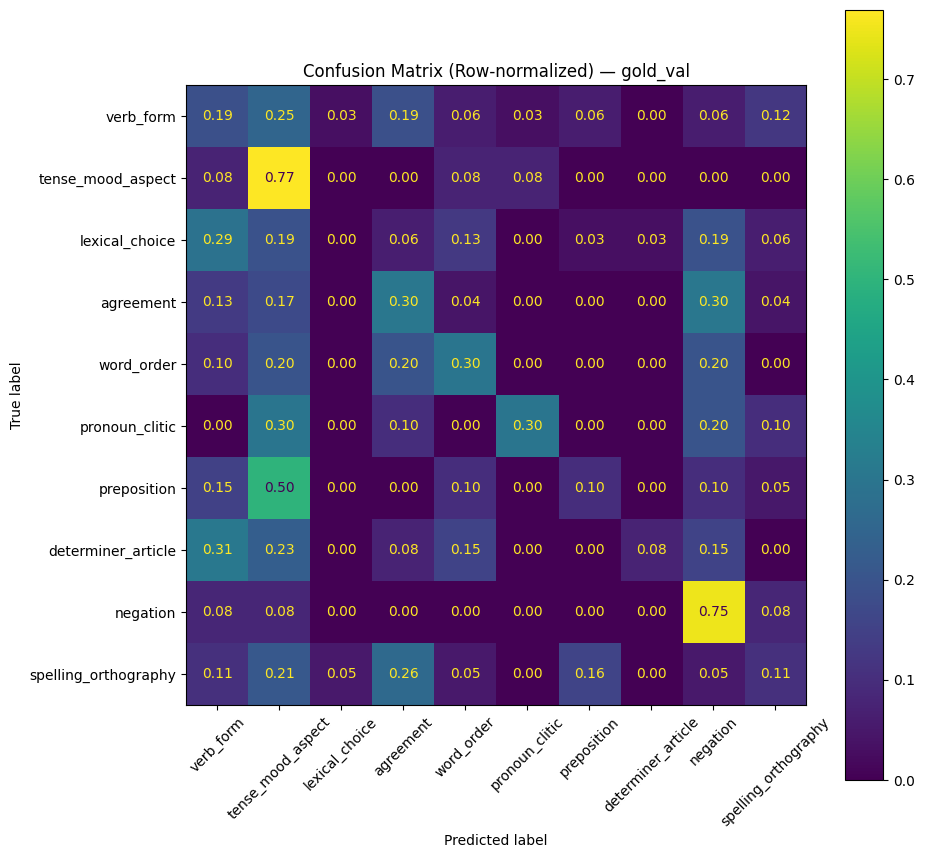

In [ ]:
# Per-label Precision / Recall / F1

print("\n=== Classification report (per label) ===")
print(classification_report(val_gold_y, val_pred, labels=LABELS, digits=3, zero_division=0))

# Confusion matrix (raw counts)
cm = confusion_matrix(val_gold_y, val_pred, labels=LABELS)

print("\n=== Confusion matrix (counts) ===")
print(cm)

# Confusion matrix plot (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (Counts) — gold_val")
plt.show()

# Confusion matrix plot (normalized by true label rows)
cm_norm = confusion_matrix(val_gold_y, val_pred, labels=LABELS, normalize="true")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix (Row-normalized) — gold_val")
plt.show()


I trained on synthetic data only (train_syn) and evaluated on the real gold validation set (gold_val, n=183). Performance is limited (accuracy = 0.235, macro-F1 = 0.224), but above a rough 10-class chance level, showing the pipeline learns non-trivial signal. The model performs best on labels with strong surface cues, notably negation (F1=0.400, recall=0.750) and tense_mood_aspect (high recall=0.769), while agreement is moderate (F1=0.298). In contrast, lexical_choice is not learned (F1=0.000), suggesting that word choice errors are difficult to capture with a synthetic-only TF-IDF representation. The confusion matrix shows systematic confusions (e.g., lexical_choice predicted as verb/tense-related classes), indicating that several categories overlap strongly in real sentences and/or that synthetic training patterns do not fully match the gold validation distribution.

#Experiment 2 — Real-only training (TF-IDF word 1–2 + Logistic Regression).

I keep the exact same pipeline (same preprocessing, same TF-IDF settings, same Logistic Regression model) and change only the training data. In this setting, the model is trained on the small REAL dataset (train_real, multi-error sentences with a single assigned label) and evaluated on the same real gold validation set (gold_val). This experiment tests whether real data alone—despite being limited in size—can produce a stronger match to the gold distribution than synthetic-only training.

In [ ]:
#apply Vectorizer on train_real
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(train_real_X)

#transform
train_real_features = vectorizer.transform(train_real_X)
val_features = vectorizer.transform(val_gold_X)

print(train_real_features.shape, len(train_real_y))
print(val_features.shape, len(val_gold_y))

# Train model on TRAIN_SYN

model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=1)
model.fit(train_real_features, train_real_y)



(398, 5137) 398
(183, 5137) 183


LogisticRegression(max_iter=1000, n_jobs=1, random_state=42)

In [ ]:
# Evaluate on VAL
val_pred  = model.predict(val_features)

print("shapes (train/val):", train_real_features.shape, val_features.shape)
print("val metrics:",  compute_metrics(val_gold_y, val_pred))

shapes (train/val): (398, 5137) (183, 5137)
val metrics: {'accuracy': 0.19672131147540983, 'macro_f1': 0.10525083612040134}


In this experiment, a TF-IDF (word n-grams 1–2) + Logistic Regression classifier was trained using only the REAL training set (≈398 sentences) and evaluated on the gold validation set. Performance was low (macro-F1 ≈ 0.10), suggesting that robust decision boundaries are difficult to learn from this small amount of real data in a 10-class setting. This outcome is consistent with the limited training size and the fact that real sentences often contain multiple competing error signals while only one label is assigned. Overall, this experiment indicates that REAL-only training is insufficient at this scale and supports using synthetic data for capacity and/or a two-stage training strategy (synthetic pretraining followed by real fine-tuning).

#Experiment 3 — Mixed training (SYN + REAL).

The same TF-IDF + Logistic Regression pipeline is kept unchanged, but the training data is expanded by concatenating the synthetic and real training sets (train_syn + train_real). Evaluation is again performed on the same gold validation set (gold_val). This experiment tests whether adding a small amount of real data to a large synthetic training pool improves generalization to realistic multi-error sentences.

In [ ]:
# --- SYN + REAL (combined) baseline: TF-IDF (1,2) + Logistic Regression ---

# Combine train sets (rows stack)
train_mix_X = pd.concat([train_syn_X, train_real_X], axis=0, ignore_index=True)
train_mix_y = pd.concat([train_syn_y, train_real_y], axis=0, ignore_index=True)

print("Mixed train size:", train_mix_X.shape, train_mix_y.shape)

# Vectorize
vectorizer = TfidfVectorizer(ngram_range=(1,2))
vectorizer.fit(train_mix_X)

train_mix_features = vectorizer.transform(train_mix_X)
val_features = vectorizer.transform(val_gold_X)

print("shapes (train/val):", train_mix_features.shape, val_features.shape)
print("len y (train/val):", len(train_mix_y), len(val_gold_y))

# 3) Train + Eval
model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=1)
model.fit(train_mix_features, train_mix_y)

val_pred = model.predict(val_features)

print("val metrics:", compute_metrics(val_gold_y, val_pred))


Mixed train size: (14739,) (14739,)
shapes (train/val): (14739, 171933) (183, 171933)
len y (train/val): 14739 183
val metrics: {'accuracy': 0.25136612021857924, 'macro_f1': 0.24623302641008554}



=== Classification report (per label) ===
                      precision    recall  f1-score   support

           verb_form      0.162     0.188     0.174        32
   tense_mood_aspect      0.227     0.769     0.351        13
      lexical_choice      0.000     0.000     0.000        31
           agreement      0.286     0.261     0.273        23
          word_order      0.214     0.300     0.250        10
      pronoun_clitic      0.667     0.400     0.500        10
         preposition      0.222     0.100     0.138        20
  determiner_article      0.333     0.077     0.125        13
            negation      0.306     0.917     0.458        12
spelling_orthography      0.250     0.158     0.194        19

            accuracy                          0.251       183
           macro avg      0.267     0.317     0.246       183
        weighted avg      0.223     0.251     0.205       183


=== Confusion matrix (counts) ===
[[ 6  8  1  6  2  1  2  0  2  4]
 [ 1 10  0  0  1  

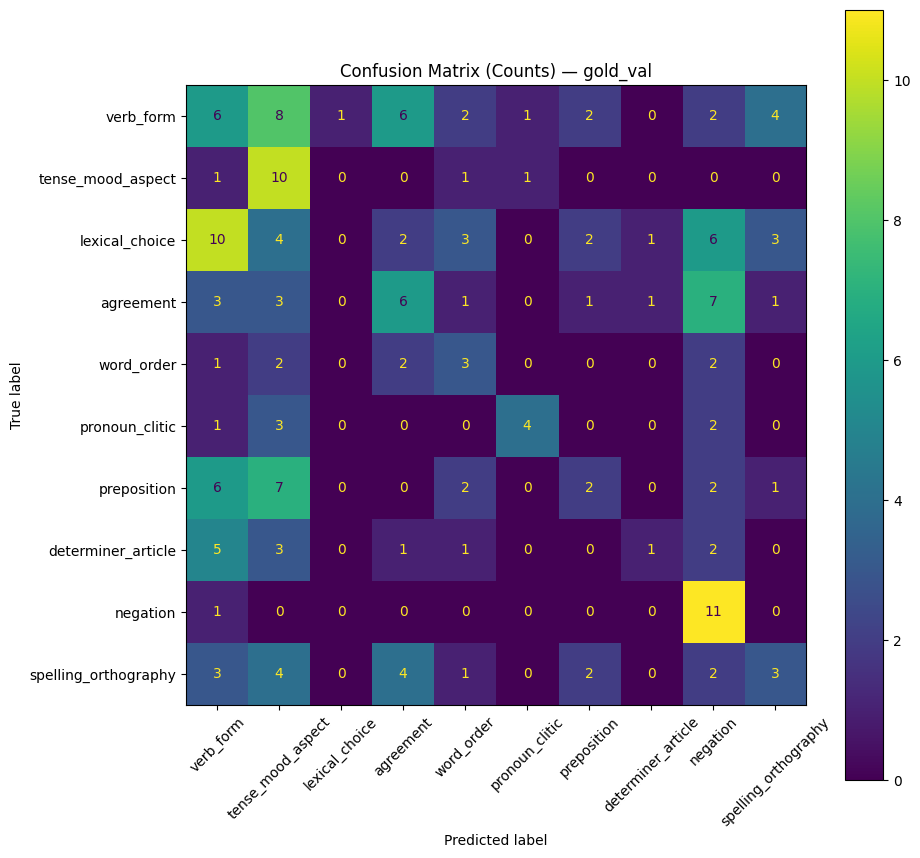

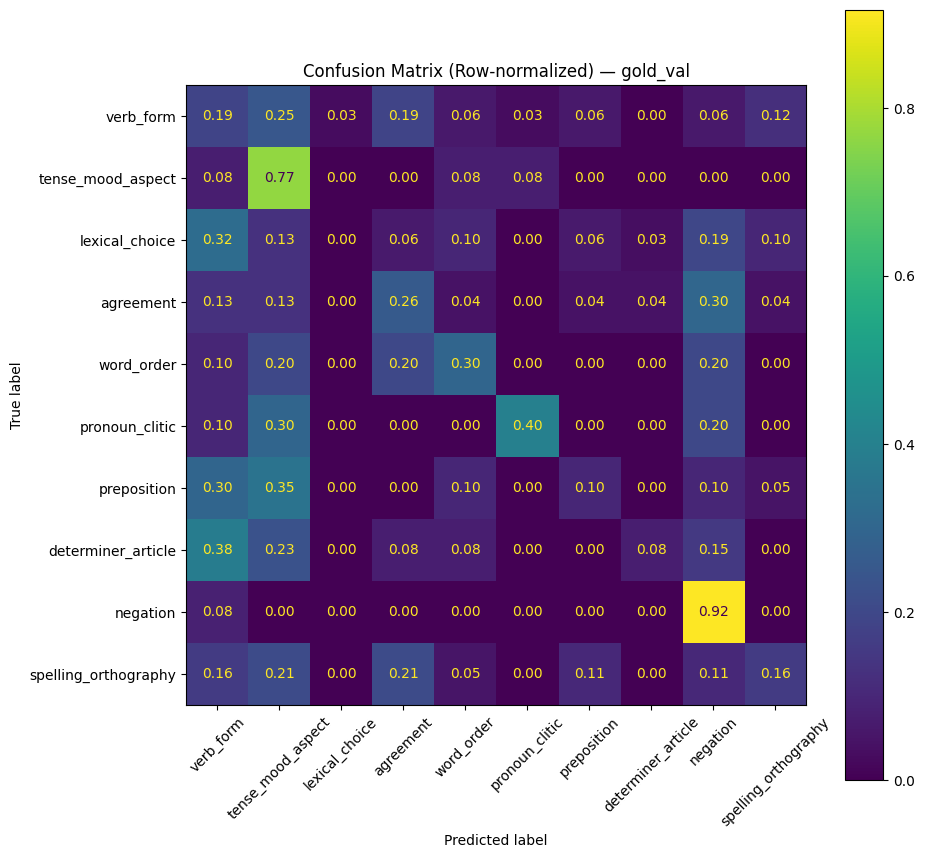

In [ ]:
# Per-label Precision / Recall / F1

print("\n=== Classification report (per label) ===")
print(classification_report(val_gold_y, val_pred, labels=LABELS, digits=3, zero_division=0))

# Confusion matrix (raw counts)
cm = confusion_matrix(val_gold_y, val_pred, labels=LABELS)

print("\n=== Confusion matrix (counts) ===")
print(cm)

# Confusion matrix plot (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (Counts) — gold_val")
plt.show()

# Confusion matrix plot (normalized by true label rows)
cm_norm = confusion_matrix(val_gold_y, val_pred, labels=LABELS, normalize="true")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix (Row-normalized) — gold_val")
plt.show()

In this experiment, a TF-IDF (word n-grams 1–2) + Logistic Regression classifier was trained on the concatenation of synthetic and real training data (≈14.7k sentences) and evaluated on the gold validation set. This mixed setting achieved the best performance among the word-level baselines (macro-F1 ≈ 0.25), outperforming both synthetic-only and real-only training. The result suggests that adding even a small amount of real data helps the model generalize better to the gold validation distribution when combined with a large synthetic dataset. Overall, this supports using synthetic data for scale while leveraging real data to improve robustness to realistic, multi-error sentences.

#Experiment 4: TF-IDF with character n-grams (3–5) on mixed synthetic + real data

In this experiment, character n-grams (3–5) are used instead of word n-grams, trained on the combined synthetic and real training data. The motivation is that character n-grams capture surface-form information such as spelling variations and morphological endings, which may be useful for error types driven by orthography and inflection (e.g. spelling, agreement, verb form). Unlike word n-grams, character n-grams allow different inflected or misspelled forms to share overlapping representations. This experiment tests whether emphasizing surface-form cues improves robustness on the gold validation set compared to word-level features.

In [ ]:
# --- SYN + REAL (combined) + char ngram_range

# Combine train sets (rows stack)
train_mix_X = pd.concat([train_syn_X, train_real_X], axis=0, ignore_index=True)
train_mix_y = pd.concat([train_syn_y, train_real_y], axis=0, ignore_index=True)

print("Mixed train size:", train_mix_X.shape, train_mix_y.shape)

# Vectorize
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5))
vectorizer.fit(train_mix_X)

train_mix_features = vectorizer.transform(train_mix_X)
val_features = vectorizer.transform(val_gold_X)

print("shapes (train/val):", train_mix_features.shape, val_features.shape)
print("len y (train/val):", len(train_mix_y), len(val_gold_y))

# 3) Train + Eval
model = LogisticRegression(max_iter=2000, random_state=42, n_jobs=1)
model.fit(train_mix_features, train_mix_y)

val_pred = model.predict(val_features)

print("val metrics:", compute_metrics(val_gold_y, val_pred))


Mixed train size: (14739,) (14739,)
shapes (train/val): (14739, 170082) (183, 170082)
len y (train/val): 14739 183
val metrics: {'accuracy': 0.2677595628415301, 'macro_f1': 0.26581261337020284}



=== Classification report (per label) for char n_gram (3,5) ===
                      precision    recall  f1-score   support

           verb_form      0.234     0.344     0.278        32
   tense_mood_aspect      0.280     0.538     0.368        13
      lexical_choice      0.600     0.097     0.167        31
           agreement      0.304     0.304     0.304        23
          word_order      0.231     0.300     0.261        10
      pronoun_clitic      0.800     0.400     0.533        10
         preposition      0.091     0.050     0.065        20
  determiner_article      0.167     0.077     0.105        13
            negation      0.323     0.833     0.465        12
spelling_orthography      0.118     0.105     0.111        19

            accuracy                          0.268       183
           macro avg      0.315     0.305     0.266       183
        weighted avg      0.312     0.268     0.241       183


=== Confusion matrix (counts) ===
[[11  3  0  4  2  1  2  1  2 

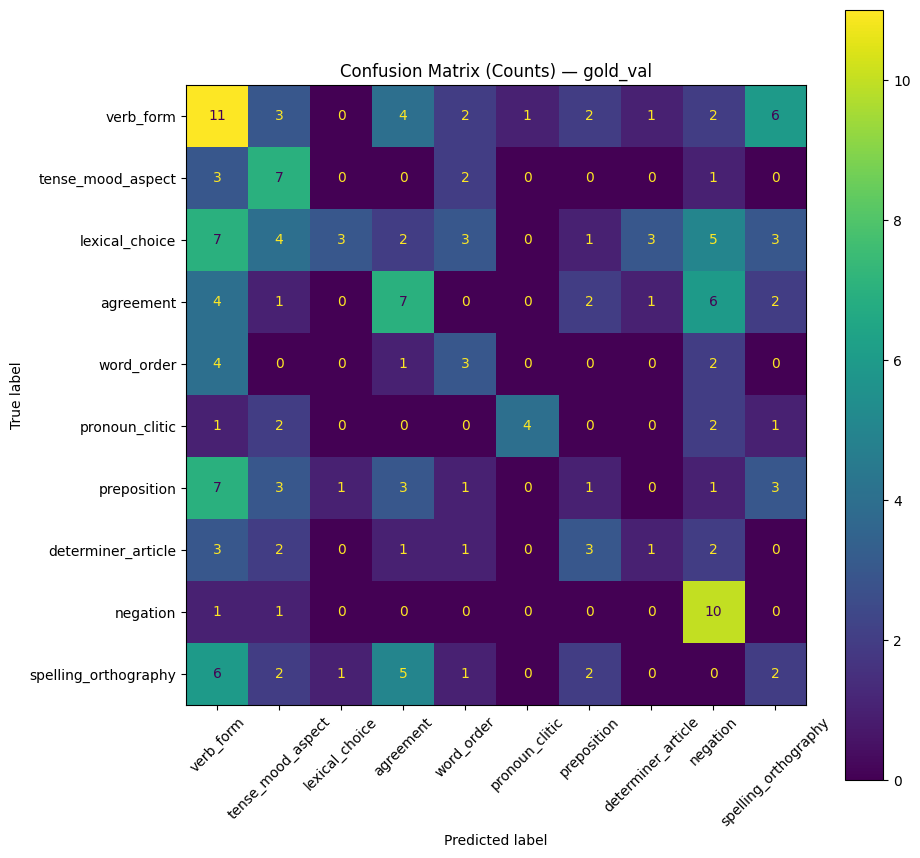

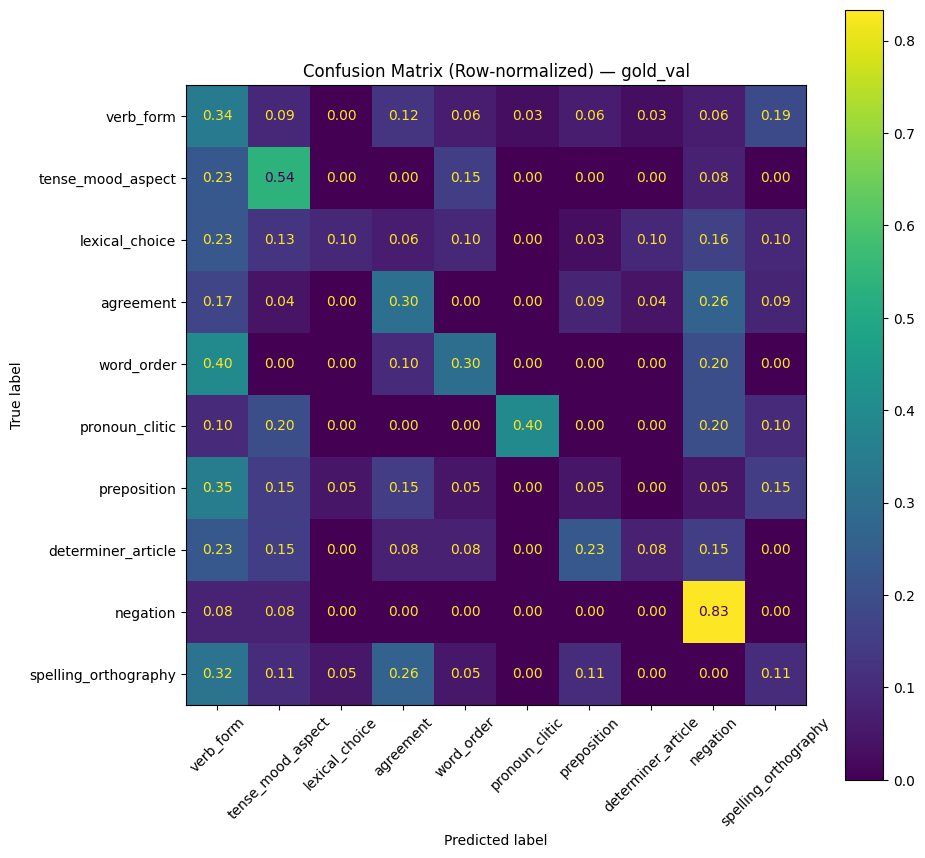

In [ ]:
# Per-label Precision / Recall / F1 for char n_gram (3,5)

print("\n=== Classification report (per label) for char n_gram (3,5) ===")
print(classification_report(val_gold_y, val_pred, labels=LABELS, digits=3, zero_division=0))

# Confusion matrix (raw counts)
cm = confusion_matrix(val_gold_y, val_pred, labels=LABELS)

print("\n=== Confusion matrix (counts) ===")
print(cm)

# Confusion matrix plot (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (Counts) — gold_val")
plt.show()

# Confusion matrix plot (normalized by true label rows)
cm_norm = confusion_matrix(val_gold_y, val_pred, labels=LABELS, normalize="true")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix (Row-normalized) — gold_val")
plt.show()

Using TF-IDF character n-grams (3–5) on the combined synthetic and real training data yields the strongest classical baseline so far, with a macro-F1 of 0.266 on the gold validation set. Compared to word n-grams, character n-grams improve overall performance and lead to clearer gains for several morpho-orthographic categories, notably negation, pronoun_clitic, agreement, and verb_form, as reflected in higher diagonal values in the row-normalized confusion matrix. However, performance remains limited for semantically driven categories such as lexical_choice, which are still heavily confused with grammatical error types. These results suggest that surface-form cues captured by character n-grams are beneficial but insufficient to fully resolve semantic ambiguity at the sentence level. This motivates the transition to contextualized transformer models, which can incorporate broader syntactic and semantic context beyond local character patterns.

#Experiment 5: Character n-grams with class-balanced training (TRAIN_SYN + TRAIN_REAL)

In this final baseline experiment, I keep the best-performing feature representation (TF-IDF character n-grams, 3–5) and introduce class-balanced logistic regression. Because the label distribution is uneven across error categories, standard training may bias the classifier toward frequent classes. Using class_weight="balanced" explicitly compensates for this imbalance by reweighting the loss contribution of each class. The goal of this experiment is not to maximize accuracy, but to assess whether balancing improves macro-level performance and recall for underrepresented error types.

In [ ]:
# --- SYN + REAL (combined) + char ngram_range + class_weight="balanced"

# Combine train sets (rows stack)
train_mix_X = pd.concat([train_syn_X, train_real_X], axis=0, ignore_index=True)
train_mix_y = pd.concat([train_syn_y, train_real_y], axis=0, ignore_index=True)

print("Mixed train size:", train_mix_X.shape, train_mix_y.shape)

# Vectorize
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5))
vectorizer.fit(train_mix_X)

train_mix_features = vectorizer.transform(train_mix_X)
val_features = vectorizer.transform(val_gold_X)

print("shapes (train/val):", train_mix_features.shape, val_features.shape)
print("len y (train/val):", len(train_mix_y), len(val_gold_y))

# 3) Train + Eval
model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42, n_jobs=1)
model.fit(train_mix_features, train_mix_y)

val_pred = model.predict(val_features)

print("val metrics:", compute_metrics(val_gold_y, val_pred))


Mixed train size: (14739,) (14739,)
shapes (train/val): (14739, 170082) (183, 170082)
len y (train/val): 14739 183
val metrics: {'accuracy': 0.2677595628415301, 'macro_f1': 0.26939560192080525}


Using class-balanced logistic regression with character n-grams (3–5) leads to a small but consistent improvement in macro-F1 (≈ 0.269 vs ≈ 0.266 without balancing), while overall accuracy remains stable. This indicates that class weighting primarily benefits underrepresented error categories by improving recall, rather than increasing global accuracy. The modest gain is expected, as class imbalance is only one of several limiting factors; overlap between error types and the presence of multiple competing error signals within a single sentence remain major sources of confusion. Nevertheless, this result confirms that reweighting classes helps the model distribute its predictions more evenly across labels.

#Final baseline conclusion

The strongest classical baseline was obtained using a TF-IDF representation with character n-grams (3–5), trained on a mixture of synthetic and real learner data, and optimized with class-balanced logistic regression. This configuration achieved a macro-F1 of approximately 0.27 on the gold validation set, outperforming word-based TF-IDF models and unbalanced training.

While overall accuracy remains limited due to substantial label overlap and the intrinsic difficulty of sentence-level error categorization, the results show that surface-level orthographic and morphological cues provide meaningful signal for several error types. At the same time, persistent confusions—especially for semantic categories such as lexical_choice—highlight the limitations of bag-of-features models.

The relatively low macro-F1 of the classical baselines reflects both the intrinsic difficulty of sentence-level error categorization in multi-error learner data and the limitations of TF-IDF representations, which cannot model syntactic structure or semantic compatibility. This motivates the use of contextualized transformer models.

This model constitutes the reference baseline for the project, and its performance (macro-F1 ≈ 0.27 on gold_val) will serve as the minimum target for transformer-based models.